# $$\text{Ejercicio Predicción - Redes Recurrentes}$$

$$\text{Serie de retornos Bitcoin}$$

**Objetivo del cuaderno:** Predecir el valor de los retornos del Bitcoin, a partir de la serie de tiempo obtenida desde la API de Yahoo Finance. Para ello se utilizarán redes recurrentes simples, LSTM unidireccionales y LSTM bidireccionales.

**Periodo de la serie:** 2015-01-01 a 2026-02-26

# 0. Librerías

In [20]:
# Libraries

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For data loading
from pathlib import Path

#Preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# Reproducibility parameters (best-effort)
tf.random.set_seed(42)
np.random.seed(42)

# 1. Importación de datos

In [10]:

# -----------------------------------------
# Data acquisition with offline fallback
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("./data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv() -> pd.DataFrame | None:
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"])
            df = df.set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None

try:
    import yfinance as yf  # pip install yfinance

    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download from yfinance.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD from Yahoo Finance. Rows: {len(df_btc)}")

    # Save cache (best-effort) if running in a writable environment
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
        print(f"💾 Cached data saved to: {out_cache.resolve()}")
    except Exception as e:
        print(f"⚠️ Could not write cache file (ok in read-only builds): {e}")

except Exception as e:
    print(f"⚠️ yfinance download failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError(
        "Could not obtain BTC data. "
        "Install yfinance and ensure internet access, OR place a cached file at data/BTC-USD.csv."
    )

# We will use the Close price
if "Close" not in df_btc.columns:
    raise ValueError(f"Expected 'Close' column. Found: {list(df_btc.columns)}")

close = df_btc[["Close"]].dropna().astype(float)
print("Date range:", close.index.min().date(), "→", close.index.max().date())
display(close.head())

✅ Downloaded BTC-USD from Yahoo Finance. Rows: 4075
💾 Cached data saved to: C:\Users\HP ENVY\Documents\Maestria_MINE\SEMESTRE 3\4.MLNN_Wilmer\redes_neuronales_git\notebooks\data\BTC-USD.csv
Date range: 2015-01-01 → 2026-02-26


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


## Crear serie de retornos

In [11]:
close["log_returns"] = np.log(close["Close"]).diff().dropna()

close.head()

Price,Close,log_returns
Ticker,BTC-USD,
Date,,
2015-01-01,314.248993,NaN
2015-01-02,315.032013,0.002489
2015-01-03,281.082001,-0.114028
2015-01-04,264.195007,-0.061959
2015-01-05,274.473999,0.038169


In [12]:
print(f"Nulos encontrados: {close['log_returns'].isna().sum()}")

Nulos encontrados: 1


In [15]:
close.drop(close.index[0], inplace=True)

close.head()

Price,Close,log_returns
Ticker,BTC-USD,
Date,,
2015-01-02,315.032013,0.002489
2015-01-03,281.082001,-0.114028
2015-01-04,264.195007,-0.061959
2015-01-05,274.473999,0.038169
2015-01-06,286.188995,0.041796


In [16]:
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4074 entries, 2015-01-02 to 2026-02-26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, BTC-USD)  4074 non-null   float64
 1   (log_returns, )   4074 non-null   float64
dtypes: float64(2)
memory usage: 95.5 KB


## Gráfico de retornos(serie)

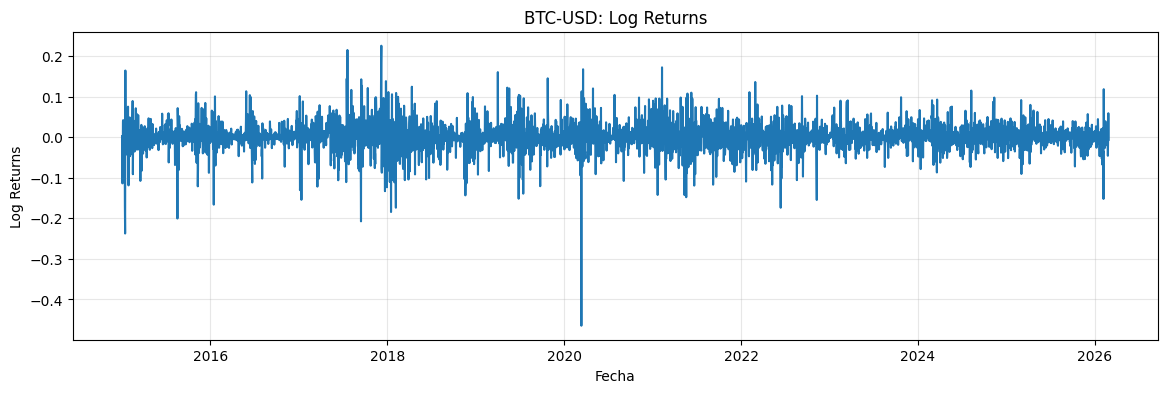

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(close.index, close["log_returns"].values)
plt.title("BTC-USD: Log Returns")
plt.xlabel("Fecha")
plt.ylabel("Log Returns")
plt.grid(True, alpha=0.3)
plt.show()

## Gráfico de retornos(distribución)

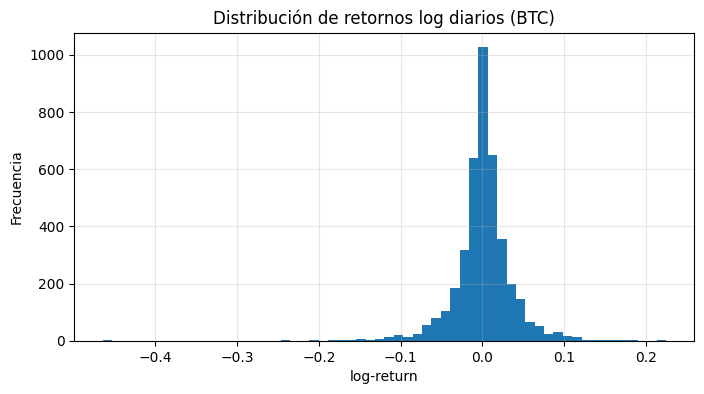

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(close["log_returns"].values, bins=60)
plt.title("Distribución de retornos log diarios (BTC)")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

## Gráfico Precio de cierre diario

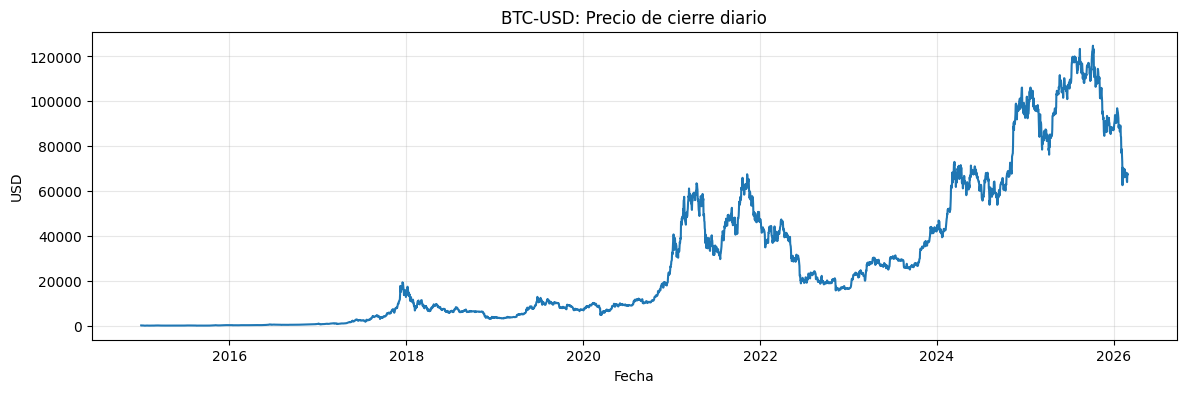

In [19]:
# Precio de cierre de BTC-USD desde 2015-01-01 hasta la fecha más reciente disponible.
plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Close"].values)
plt.title("BTC-USD: Precio de cierre diario")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Preprocesamiento de datos

In [25]:
data1 = close.drop(columns=["Close"])
data1.head()

Price,log_returns
Ticker,
Date,
2015-01-02,0.002489
2015-01-03,-0.114028
2015-01-04,-0.061959
2015-01-05,0.038169
2015-01-06,0.041796


In [26]:
# Convert to numpy
data = data1.values  # shape (T, 1)

data

array([[ 0.00248862],
       [-0.11402782],
       [-0.06195895],
       ...,
       [-0.00834051],
       [ 0.05878816],
       [-0.00670523]], shape=(4074, 1))

In [27]:
# Train/Test split (time-based) -> train:90% / test:10%
LOOK_BACK = 90

# We split BEFORE scaling to avoid leakage
split_idx = int(len(data) * 0.90)
train_raw = data[:split_idx]
test_raw = data[split_idx:]

scaler = MinMaxScaler(feature_range=(-1, 1)) # LSTM con función de activación tanh suele funcionar mejor con datos centrados en 0
train_scaled = scaler.fit_transform(train_raw) # Fit only on train to avoid data leakage
test_scaled = scaler.transform(test_raw) # Use the same scaler to transform test data

def make_windows(series_2d: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build supervised windows from a univariate series (T, 1).

    Returns:
        X: (N, look_back, 1)
        y: (N, 1)
    """
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_test, y_test = make_windows(test_scaled, LOOK_BACK)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


X_train: (3576, 90, 1) y_train: (3576, 1)
X_test : (318, 90, 1) y_test : (318, 1)


# 3. Naïve forecast(baseline)

In [28]:
# Baseline: predict y_t as the last value in the window (scaled)
baseline_pred_scaled = X_test[:, -1, 0].reshape(-1, 1)

# Back to real prices
y_test_real = scaler.inverse_transform(y_test)
baseline_pred_real = scaler.inverse_transform(baseline_pred_scaled)

def rmse(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

baseline_rmse = rmse(y_test_real, baseline_pred_real)
baseline_mae = float(mean_absolute_error(y_test_real, baseline_pred_real))

print(f"Return Baseline (tomorrow=today) | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

Return Baseline (tomorrow=today) | RMSE: 0.03 | MAE: 0.02


# 4. Arquitecturas de la red RNN

## 4.1 Prueba 1

Parámetros:

- LOOK_BACK -> 90 días
- Dropout entre capas LSTM bidireccionales -> 0.2
- N° de unidades de cada capa LSTM bidireccional -> 70
- función de activación en la capa de predicción: relu
- función de pérdida -> mse
- EarlyStopping - Patience -> 5
- epochs -> 50

### 4.1.a. Instanciar el modelo

In [29]:
model_90 = Sequential([
    Bidirectional(LSTM(units=70, return_sequences=True), input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(units=70, return_sequences=False)), # Esta capa procesa la salida de la primera y, al final, solo entrega un "resumen" vectorial con la información más importante de toda la secuencia. Como es bidireccional con 50 unidades, entregará un vector de 100 números a la siguiente capa.
    Dropout(0.2),
    Dense(35, activation="relu"), # Una capa intermedia que ayuda a interpretar las características complejas extraídas por las LSTMs. Usa la activación ReLU, que es excelente para que la red aprenda relaciones no lineales de forma rápida.
    Dense(1)
])

model_90.compile(optimizer="adam", loss="mse")
model_90.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]
# EarlyStopping -> Detiene el entrenamiento si la validación no mejora durante 5 épocas, 
# y restaura los pesos del mejor modelo encontrado. Esto previene el sobreajuste y ahorra tiempo.

# ReduceLROnPlateau -> Si el modelo deja de mejorar en validación durante 3 épocas, 
# reduce la tasa de aprendizaje a la mitad. 
# Esto ayuda a que el modelo escape de mínimos locales y siga mejorando.

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 90, 140)        │        40,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 140)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 140)            │       118,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 35)             │         4,935 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,451 (638.48 KB)

 Trainable params: 163,451 (638.48 KB)

 Non-trainable params: 0 (0.00 B)

### 4.1.b. Entrenamiento de la red neuronal

In [30]:
history_90 = model_90.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - loss: 0.0141 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0118 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0115 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - loss: 0.0114 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - loss: 0.0113 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - loss: 0.0113 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - loss: 0.0112 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 217ms/step - loss: 0.0112 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 9/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - loss: 0.0111 - val_loss: 0.

### 4.1.c. Gráfico de curva de aprendizaje

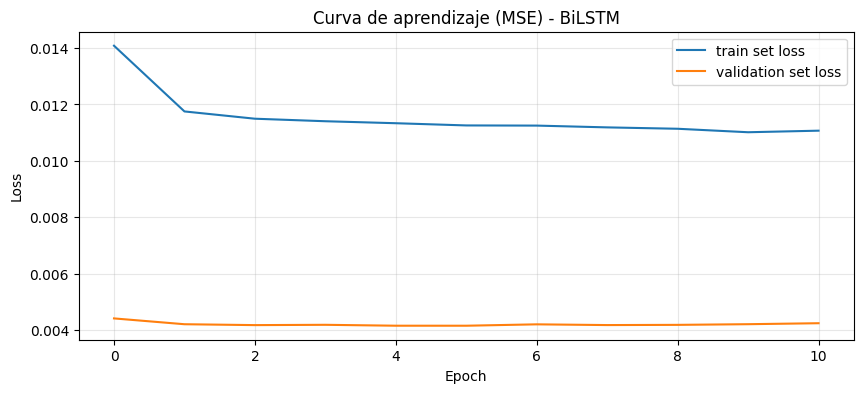

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(model_90.history.history["loss"], label="train set loss")
plt.plot(model_90.history.history["val_loss"], label="validation set loss")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.1.d. Evaluación

In [34]:

pred_scaled_90 = model_90.predict(X_test, verbose=0)

pred_real_90 = scaler.inverse_transform(pred_scaled_90)
y_test_real = scaler.inverse_transform(y_test)

model_rmse_90 = rmse(y_test_real, pred_real_90)
model_mae_90 = float(mean_absolute_error(y_test_real, pred_real_90))

print(f"BiLSTM | RMSE: {model_rmse_90:.2f} | MAE: {model_mae_90:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

BiLSTM | RMSE: 0.02 | MAE: 0.02
Baseline | RMSE: 0.03 | MAE: 0.02


### 4.1.e. Gráfico de predicción vs real vs baseline

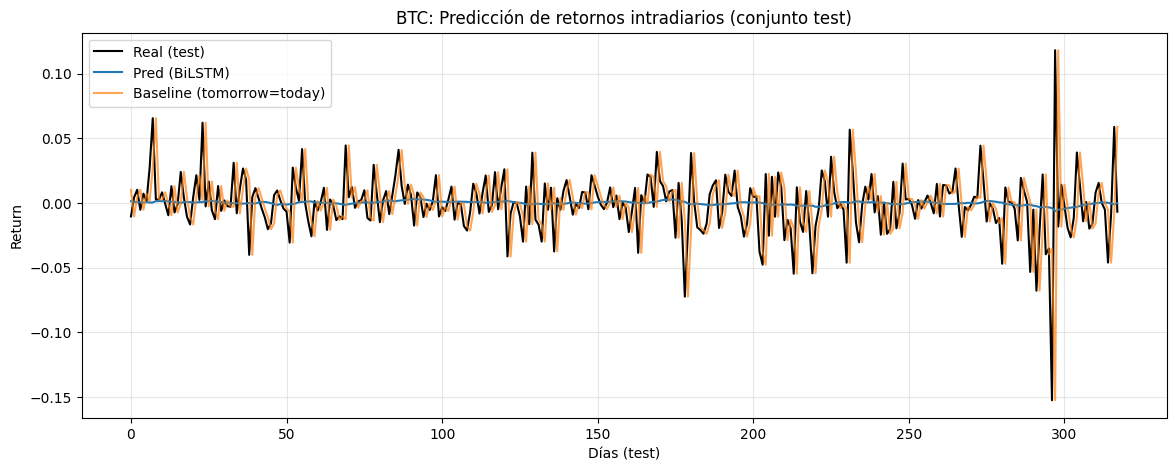

In [37]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real_90, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de retornos intradiarios (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

* A diferencia de los precios, los retornos son mayormente "ruido blanco" con una media cercana a cero.

* Para la red neuronal, la forma más fácil de minimizar el error cuadrático medio (MSE) es predecir siempre un valor cercano a la media. Si predice $0$ y el retorno real es $0.05$, el error es pequeño. Si intenta predecir $0.05$ y el mercado cae $-0.05$, el error es enorme. -> predecir volatilidad se castiga en la función de pérdida

* Un `LOOK_BACK` de 90 días puede ser demasiado largo para retornos y el modelo termina ignorando la secuencia

## 4.2 Prueba 2

Parámetros:
    
- LOOK_BACK -> 30 días
- Dropout entre capas LSTM bidireccionales -> 0.1
- N° de unidades de cada capa LSTM bidireccional -> 70
- función de activación en la capa de predicción -> tanh
- función de pérdida -> mae
- EarlyStopping - Patience -> 10
- epochs -> 100

### 4.2.a. Instanciar el modelo

In [38]:
model_30 = Sequential([
    Bidirectional(LSTM(units=70, return_sequences=True), input_shape=(30, 1)),
    Dropout(0.1),
    Bidirectional(LSTM(units=70, return_sequences=False)), # Esta capa procesa la salida de la primera y, al final, solo entrega un "resumen" vectorial con la información más importante de toda la secuencia. Como es bidireccional con 50 unidades, entregará un vector de 100 números a la siguiente capa.
    Dropout(0.1),
    Dense(35, activation="tanh"), # Una capa intermedia que ayuda a interpretar las características complejas extraídas por las LSTMs. Usa la activación ReLU, que es excelente para que la red aprenda relaciones no lineales de forma rápida.
    Dense(1)
])

model_30.compile(optimizer="adam", loss="mae") # Para esta versión, cambiamos a MAE, que es más robusta a outliers y puede ser más interpretativa en términos de error promedio en unidades reales.
model_30.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 30, 140)        │        40,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 140)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 140)            │       118,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         4,935 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,451 (638.48 KB)

 Trainable params: 163,451 (638.48 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2.b. Entrenamiento de la red neuronal

In [39]:
history_30 = model_30.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - loss: 0.0804 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - loss: 0.0721 - val_loss: 0.0442 - learning_rate: 0.0010
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0707 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0697 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0698 - val_loss: 0.0437 - learning_rate: 0.0010
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0692 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - loss: 0.0690 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - loss: 0.0688 - val_loss: 0.0458 - learning_rate: 0.0010
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 167ms/step - loss: 0.0688 - val_loss: 0.044

### 4.2.c. Gráfico de curva de aprendizaje

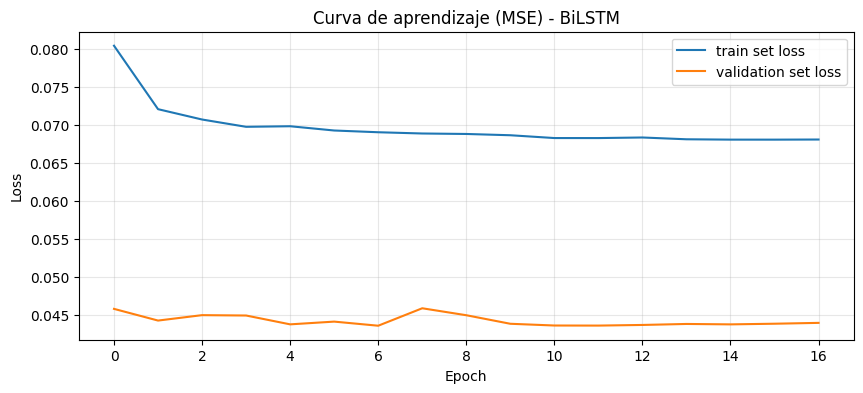

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(model_30.history.history["loss"], label="train set loss")
plt.plot(model_30.history.history["val_loss"], label="validation set loss")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.2.d. Evaluación

In [41]:
pred_scaled_30 = model_30.predict(X_test, verbose=0)

pred_real_30 = scaler.inverse_transform(pred_scaled_30)
y_test_real = scaler.inverse_transform(y_test)

model_rmse_30 = rmse(y_test_real, pred_real_30)
model_mae_30 = float(mean_absolute_error(y_test_real, pred_real_30))

print(f"BiLSTM | RMSE: {model_rmse_30:.2f} | MAE: {model_mae_30:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

BiLSTM | RMSE: 0.02 | MAE: 0.02
Baseline | RMSE: 0.03 | MAE: 0.02


### 4.2.e. Gráfico de predicción vs real vs baseline

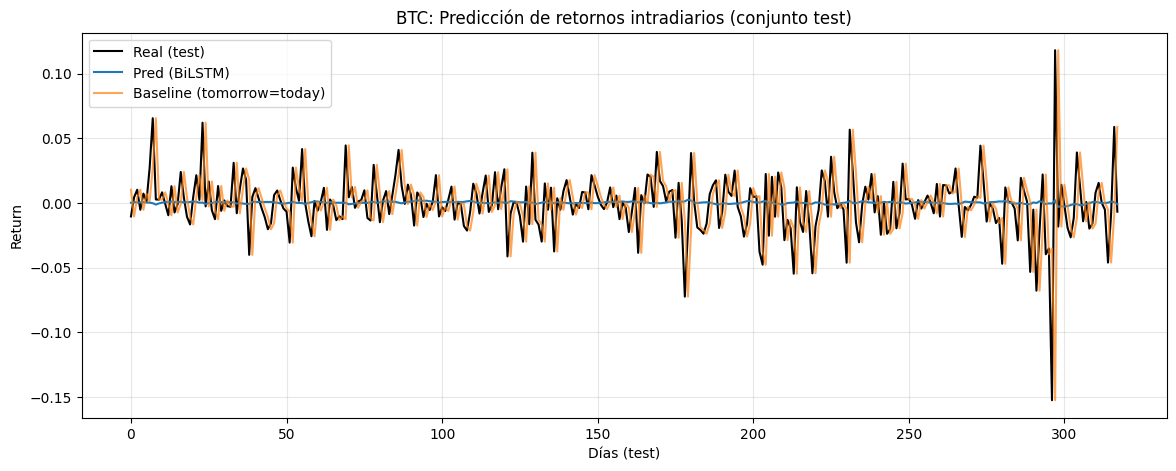

In [42]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real_30, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de retornos intradiarios (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4.3 Prueba 3

Parámetros:
    
- LOOK_BACK -> 7 días
- Dropout entre capas LSTM bidireccionales -> 0.1
- N° de unidades de cada capa LSTM bidireccional -> 70
- función de activación en la capa de predicción -> tanh
- función de pérdida -> mae
- EarlyStopping - Patience -> 10
- epochs -> 100
- Sin callback `ReduceLROnPlateau`

### 4.3.a. Instanciar el modelo

In [44]:
from tensorflow.keras.optimizers import Adam

In [45]:
model_7 = Sequential([
    Bidirectional(LSTM(units=70, return_sequences=True), input_shape=(7, 1)),
    Dropout(0.1),
    Bidirectional(LSTM(units=70, return_sequences=False)), # Esta capa procesa la salida de la primera y, al final, solo entrega un "resumen" vectorial con la información más importante de toda la secuencia. Como es bidireccional con 50 unidades, entregará un vector de 100 números a la siguiente capa.
    Dropout(0.1),
    Dense(35, activation="tanh"), # Una capa intermedia que ayuda a interpretar las características complejas extraídas por las LSTMs. Usa la activación ReLU, que es excelente para que la red aprenda relaciones no lineales de forma rápida.
    Dense(1)
])

model_7.compile(optimizer=Adam(learning_rate = 0.001), loss="mae")
model_7.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    # ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 7, 140)         │        40,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 140)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 140)            │       118,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 35)             │         4,935 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,451 (638.48 KB)

 Trainable params: 163,451 (638.48 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3.b. Entrenamiento de la red neuronal

In [46]:
history_7 = model_7.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - loss: 0.0773 - val_loss: 0.0437
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0718 - val_loss: 0.0464
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 31s 202ms/step - loss: 0.0705 - val_loss: 0.0441
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - loss: 0.0700 - val_loss: 0.0439
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - loss: 0.0696 - val_loss: 0.0437
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 190ms/step - loss: 0.0691 - val_loss: 0.0435
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - loss: 0.0690 - val_loss: 0.0444
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 197ms/step - loss: 0.0687 - val_loss: 0.0436
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - loss: 0.0687 - val_loss: 0.0442
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 222ms/step - loss: 0.0688 - val_loss: 0.0440
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 237ms/step - loss: 0.0686 - val_loss: 0.0437
Epoch 12

### 4.3.c. Gráfico de curva de aprendizaje

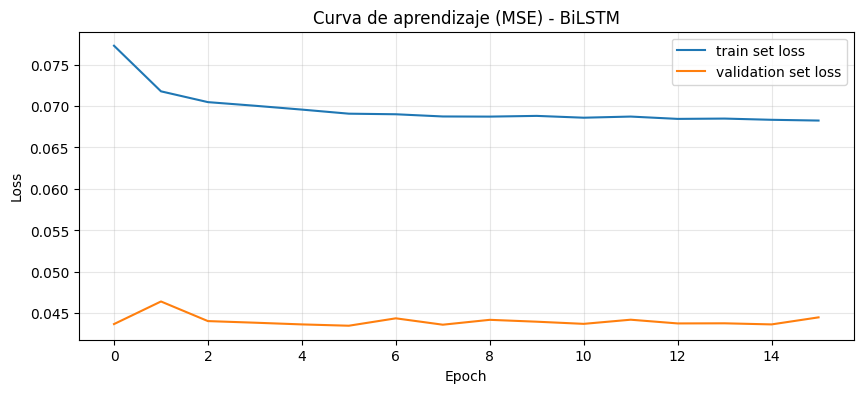

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(model_7.history.history["loss"], label="train set loss")
plt.plot(model_7.history.history["val_loss"], label="validation set loss")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.3.d. Evaluación

In [48]:
pred_scaled_7 = model_7.predict(X_test, verbose=0)

pred_real_7 = scaler.inverse_transform(pred_scaled_7)
y_test_real = scaler.inverse_transform(y_test)

model_rmse_7 = rmse(y_test_real, pred_real_7)
model_mae_7 = float(mean_absolute_error(y_test_real, pred_real_7))

print(f"BiLSTM | RMSE: {model_rmse_7:.2f} | MAE: {model_mae_7:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")


BiLSTM | RMSE: 0.02 | MAE: 0.02
Baseline | RMSE: 0.03 | MAE: 0.02


### 4.3.e. Gráfico de predicción vs real vs baseline

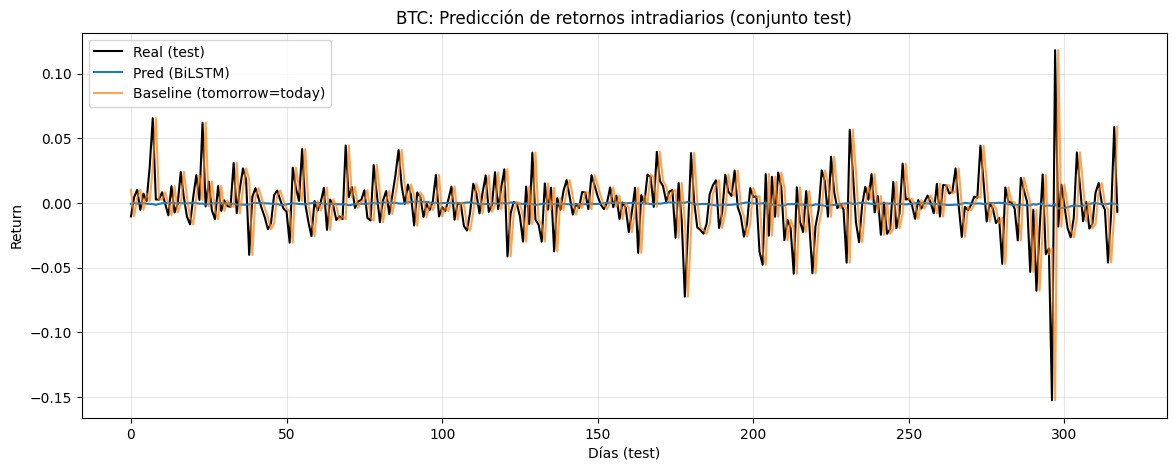

In [49]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real_7, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de retornos intradiarios (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4.4 Prueba 4

Parámetros:
    
- LOOK_BACK -> 7 días
- Sin Dropout entre capas LSTM bidireccionales
- N° de unidades -> 140
- función de activación en la capa LSTM -> tanh
- función de pérdida -> mae
- epochs -> 100
- Sin callbacks
- learning_rate -> 0.001

### 4.4.a. Instanciar el modelo

In [50]:
model_7b = Sequential([
    LSTM(140, activation='tanh', input_shape=(7, 1)),
    Dense(1) # Sin activación para dejar que el valor fluya libre
])

model_7b.compile(optimizer=Adam(learning_rate = 0.001), loss="mae")
model_7b.summary()

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 140)            │        79,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           141 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,661 (311.18 KB)

 Trainable params: 79,661 (311.18 KB)

 Non-trainable params: 0 (0.00 B)

### 4.4.b. Entrenamiento de la red neuronal

In [51]:
history_7b = model_7b.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
    # ,
    # callbacks=callbacks
)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - loss: 0.0778 - val_loss: 0.0443
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0704 - val_loss: 0.0468
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 0.0700 - val_loss: 0.0443
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0697 - val_loss: 0.0438
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0691 - val_loss: 0.0440
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0690 - val_loss: 0.0440
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0691 - val_loss: 0.0443
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0689 - val_loss: 0.0437
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.0687 - val_loss: 0.0442
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0687 - val_loss: 0.0438
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - loss: 0.0685 - val_loss: 0.0441
Epoch 12/100
112/112 ━━━

### 4.4.c. Gráfico de curva de aprendizaje

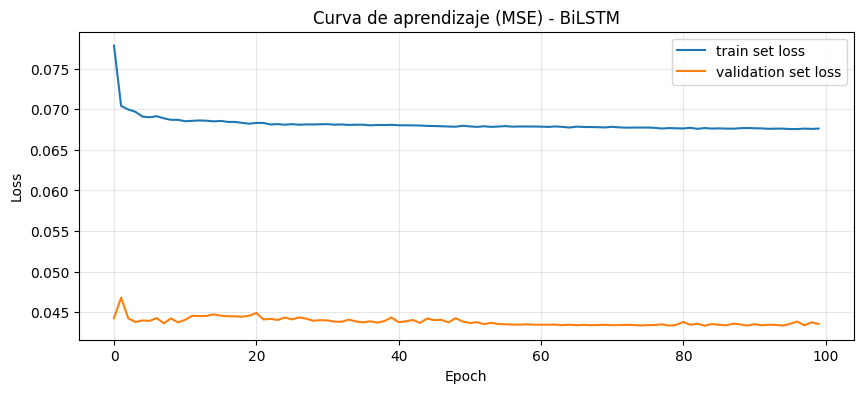

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(model_7b.history.history["loss"], label="train set loss")
plt.plot(model_7b.history.history["val_loss"], label="validation set loss")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.4.d. Evaluación

In [53]:
pred_scaled_7b = model_7b.predict(X_test, verbose=0)

pred_real_7b = scaler.inverse_transform(pred_scaled_7b)
y_test_real = scaler.inverse_transform(y_test)

model_rmse_7b = rmse(y_test_real, pred_real_7b)
model_mae_7b = float(mean_absolute_error(y_test_real, pred_real_7b))

print(f"BiLSTM | RMSE: {model_rmse_7b:.2f} | MAE: {model_mae_7b:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

BiLSTM | RMSE: 0.02 | MAE: 0.02
Baseline | RMSE: 0.03 | MAE: 0.02


### 4.4.e. Gráfico de predicción vs real vs baseline

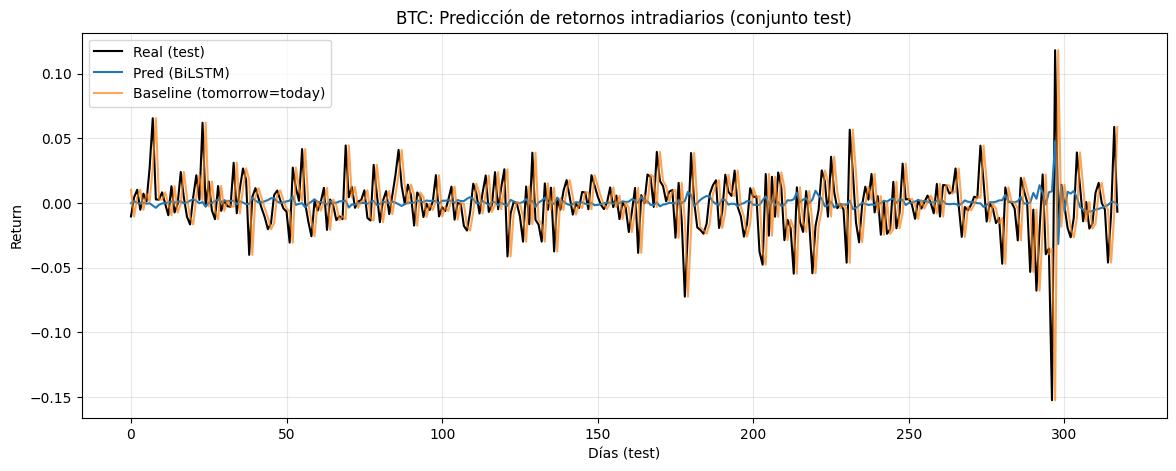

In [54]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real_7b, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de retornos intradiarios (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4.5 Prueba 5

Parámetros:
    
- LOOK_BACK -> 3 días
- Dropout -> 0.05
- N° de unidades -> 140
- función de activación en la capa LSTM bidireccional -> tanh
- función de pérdida -> mae
- epochs -> 100
- callbacks -> EarlyStopping
- learning_rate -> 0.001

### 4.5.a. Instanciar el modelo

In [55]:
model_7c = Sequential([
    Bidirectional(LSTM(units=140, return_sequences=True), input_shape=(3, 1)),
    Dropout(0.05),
    Dense(1) # Sin activación para dejar que el valor fluya libre
])

model_7c.compile(optimizer=Adam(learning_rate = 0.001), loss="mae")
model_7c.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    ,
    # ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_8 (Bidirectional) │ (None, 3, 280)         │       159,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3, 1)           │           281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,321 (622.35 KB)

 Trainable params: 159,321 (622.35 KB)

 Non-trainable params: 0 (0.00 B)

### 4.5.b. Entrenamiento de la red neuronal

In [56]:
history_7c = model_7c.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - loss: 0.0818 - val_loss: 0.0480
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0727 - val_loss: 0.0464
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0713 - val_loss: 0.0455
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0704 - val_loss: 0.0449
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0699 - val_loss: 0.0445
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0695 - val_loss: 0.0443
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - loss: 0.0693 - val_loss: 0.0442
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - loss: 0.0691 - val_loss: 0.0442
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - loss: 0.0690 - val_loss: 0.0441
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - loss: 0.0688 - val_loss: 0.0439
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 167ms/step - loss: 0.0687 - val_loss: 0.0439
Epoch 12

### 4.5.c. Gráfico de curva de aprendizaje

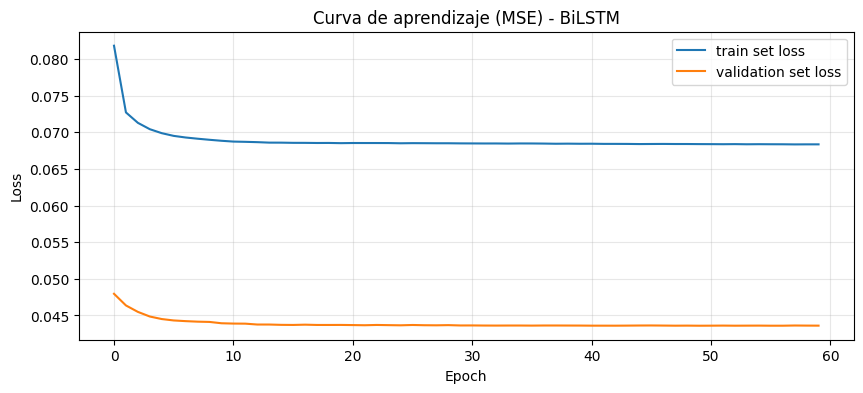

In [57]:
plt.figure(figsize=(10, 4))
plt.plot(model_7c.history.history["loss"], label="train set loss")
plt.plot(model_7c.history.history["val_loss"], label="validation set loss")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.5.d. Evaluación

In [59]:
pred_scaled_7c = model_7c.predict(X_test, verbose=0)

# 1. Aplanamos el array de (N, 1, 1) a (N, 1)
pred_scaled_2d = pred_scaled_7c.reshape(-1, 1)

# 2. Ahora aplicamos la transformación inversa
pred_real_7c = scaler.inverse_transform(pred_scaled_2d)

# pred_real_7c = scaler.inverse_transform(pred_scaled_7c)
y_test_real = scaler.inverse_transform(y_test)

model_rmse_7c = rmse(y_test_real, pred_real_7c)
model_mae_7c = float(mean_absolute_error(y_test_real, pred_real_7c))

print(f"BiLSTM | RMSE: {model_rmse_7c:.2f} | MAE: {model_mae_7c:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

ValueError: Found input variables with inconsistent numbers of samples: [318, 28620]

### 4.5.e. Gráfico de predicción vs real vs baseline

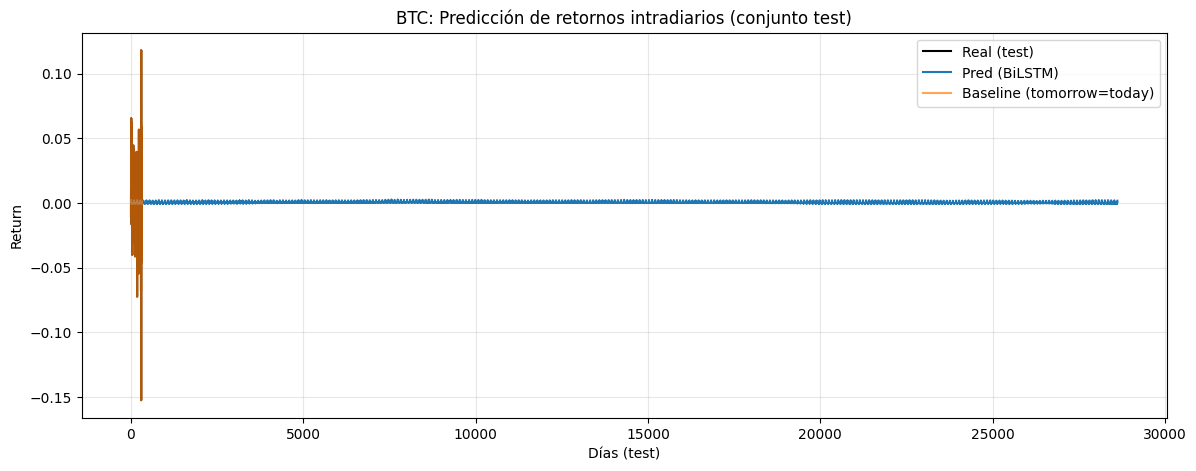

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real_7c, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de retornos intradiarios (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Conclusiones

El modelo que mejor ajuste mostró a la tendencia de la serie original fue el de la `prueba 4`

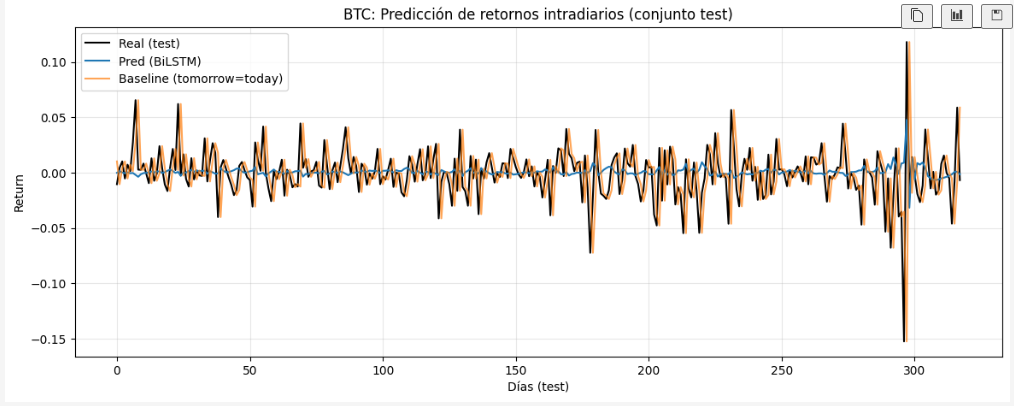

# 6. Guardar el modelo preentrenado

In [61]:
# Save Keras model
model_out = Path("./models/returnsbtc_bilstm_julian.keras")
try:
    model_out.parent.mkdir(parents=True, exist_ok=True)
    # Nombre del modelo a guardar
    model_7b.save(model_out)
    print(f"✅ Model saved to: {model_out.resolve()}")
except Exception as e:
    print(f"⚠️ Could not save model (ok in read-only builds): {e}")

✅ Model saved to: C:\Users\HP ENVY\Documents\Maestria_MINE\SEMESTRE 3\4.MLNN_Wilmer\redes_neuronales_git\notebooks\models\returnsbtc_bilstm_julian.keras


# 9. Reconstrucción del precio

Acumulando retornos